---
## ⚙️ Setup — Run this first!

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time
import math

# Check if GPU is available
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ No GPU detected. Go to Runtime → Change runtime type → GPU")
    print("   (Some demos will still work, just slower)")

print("\n✅ Setup complete! Ready to go.")

PyTorch version: 2.14.0+cu130
GPU available: True
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU

✅ Setup complete! Ready to go.


---
# Part 1: Tensors — Building Intuition
*(After Slides 4-11)*

---

### 1.1 Scalars, Vectors, Matrices, Tensors
Let's create each one and see what makes them different.

In [2]:
raghu_age = torch.tensor(21.0)

In [3]:
print(raghu_age)

tensor(21.)


In [4]:
vector = torch.tensor([1.0, 2.0, 3.0, 4.0])

In [5]:
print(vector)

tensor([1., 2., 3., 4.])


In [6]:
print(vector.dim())

1


In [7]:
print(raghu_age.dim())

0


In [8]:
# A scalar - just a number
scalar = torch.tensor(42.0)
print(f"Scalar: {scalar}")
print(f"   Shape: {scalar.shape}")        # torch.size([])
print(f"   Dimensions: {scalar.dim()}")   # 0
print()

# A vector - a list of numbers
vector = torch.tensor([1.0, 2.0, 3.0, 4.0])
print(f"Vector: {vector}")
print(f"   Shape: {vector.shape}")       # torch.size([4])
print(f"   Dimensions: {vector.dim()}")  # 1
print()

# A matrix - a grid of numbers
matrix = torch.tensor([[1, 2, 3],
                       [4, 5, 6]])
print(f"Matrix:\n{matrix}")
print(f"  Shape: {matrix.shape}")        # torch.size([2, 3])
print(f"  Dimensions: {matrix.dim()}")   # 2
print()

# A 3D tensor - a cube of numbers
tensor_3d = torch.zeros(2, 3, 4)
print(f"3D Tensor shape: {tensor_3d.shape}")  # [2, 3, 4]
print(f"   Dimensions: {tensor_3d.dim()}")    # 3
print()

# A 4D tensor - like a batch going through multi-head attention
tensor_4d = torch.zeros(8, 12, 3, 64)
print(f"4D Tensor shape: {tensor_4d.shape}")  # [8, 12, 3, 64]
print(f"  That's: 8 sentences x 12 heads x 3 tokens x 64 dims")

Scalar: 42.0
   Shape: torch.Size([])
   Dimensions: 0

Vector: tensor([1., 2., 3., 4.])
   Shape: torch.Size([4])
   Dimensions: 1

Matrix:
tensor([[1, 2, 3],
        [4, 5, 6]])
  Shape: torch.Size([2, 3])
  Dimensions: 2

3D Tensor shape: torch.Size([2, 3, 4])
   Dimensions: 3

4D Tensor shape: torch.Size([8, 12, 3, 64])
  That's: 8 sentences x 12 heads x 3 tokens x 64 dims


### 1.2 Creating Tensors — Many Ways

In [9]:
z = torch.zeros(3, 4)

In [10]:
o = torch.ones(2, 5)

In [11]:
r = torch.randn(3, 3)

In [12]:
seq = torch.arange(0, 10)

In [13]:
lin = torch.linspace(0, 1, 5)

In [14]:
# Zeros and ones
z = torch.zeros(3, 4)       # 3x4 matrix of zeros
o = torch.ones(2, 5)        # 2x5 matrix of ones

# Random (normal distribution) - this is how weights statt!
r = torch.randn(3, 3)       # random values, mean=0, std=1
print("Random matrix (this is how neural network weights begin):")
print(r)
print()

# From a range
seq = torch.arange(0, 10)   # [0, 1, 2, ..., 9]
print(f"Sequence: {seq}")

# Linspace - evenly spaced
lin = torch.linspace(0, 1, 5)  # 5 values from 0 to 1
print(f"Linspace: {lin}")

Random matrix (this is how neural network weights begin):
tensor([[ 0.4659,  0.4329, -0.2750],
        [-1.5589,  0.0779, -2.0471],
        [ 0.5203, -1.0110, -0.6178]])

Sequence: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
Linspace: tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])


### 1.3 Shape is Everything
In deep learning, you'll check `.shape` more than anything else.

In [15]:
# Real-world shapes in deep learning
batch_size = 8
seq_len = 128
embed_dim = 768
num_heads = 12
head_dim = embed_dim // num_heads   # 64

# A batch of tokenized sentences
x = torch.randn(batch_size, seq_len, embed_dim)
print(f"Batch of sentence: {x.shape}")
print(f"   {batch_size} sentences, {seq_len} tokens, {num_heads} heads, {head_dim} dims per head")
print()

# Reshape for multi-head attention
x_heads = x.view(batch_size, seq_len, num_heads, head_dim)
print(f"After splitting into heads: {x_heads.shape}")
print(f"   {batch_size} sentences, {seq_len} tokens, {num_heads} heads, {head_dim} dims per head")
print()

# Rearrange so heads come before tokens (needed for attention)
x_ready = x_heads.permute(0, 2, 1, 3)
print(f"After permute for attention: {x_ready.shape}")
print(f"   {batch_size} sentences, {seq_len} tokens, {num_heads} heads, {head_dim} dims")
print()
print(" This is EXACTLY what happens inside transformer")

Batch of sentence: torch.Size([8, 128, 768])
   8 sentences, 128 tokens, 12 heads, 64 dims per head

After splitting into heads: torch.Size([8, 128, 12, 64])
   8 sentences, 128 tokens, 12 heads, 64 dims per head

After permute for attention: torch.Size([8, 12, 128, 64])
   8 sentences, 128 tokens, 12 heads, 64 dims

 This is EXACTLY what happens inside transformer


In [16]:
# Use 8 heads because 512 / 8 = 64
num_heads = 8
head_dim = embed_dim // num_heads

x = torch.randn(batch_size, seq_len, embed_dim)
print(f"Original shape: {x.shape}")
print(f"Number of dimensions: {x.dim()}")

x_heads = x.view(batch_size, seq_len, num_heads, head_dim)
print(f"After splitting into heads: {x_heads.shape}")

x_ready = x_heads.permute(0, 2, 1, 3)
print(f"After permutation: {x_ready.shape}")


Original shape: torch.Size([8, 128, 768])
Number of dimensions: 3
After splitting into heads: torch.Size([8, 128, 8, 96])
After permutation: torch.Size([8, 8, 128, 96])


---
# Part 2: Matrix Magic — Transformations Visualized
*(After Slides 12-21)*

---

### 2.1 Matrix × Vector = Transformation
A matrix doesn't just store numbers — it *transforms* vectors.

In [17]:
# A vector pointing right
v = torch.tensor([1.0, 0.0])
print(f"Original vector: {v.tolist()}")

# Rotation matrix (90 degrees counterclockwise)
rotate_90 = torch.tensor([[0., -1.],
                          [1., 0.]])

rotated = rotate_90 @ v
print(f"After 90 degree roatation: {rotated.tolist()}")  # [0, 1] -> pointing up!

# Rotation matrix (45 degrees)
angle = math.radians(45)
rotate_45 = torch.tensor([[math.cos(angle), -math.sin(angle)],
                          [math.sin(angle), math.cos(angle)]])

rotated_45 = rotate_45 @ v
print(f"After 45 degree rotation: [{rotated_45[0]:.3f}, {rotated_45[1]:.3f}]")

Original vector: [1.0, 0.0]
After 90 degree roatation: [0.0, 1.0]
After 45 degree rotation: [0.707, 0.707]


### 2.2 🔥 Visualizing Transformations
Watch a matrix transform an entire grid of points!

In [18]:
def plot_transformation(matrix, title="Transformation"):
    """Visualize how a 2x2 matrix transforms a grid of points."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Create a grid of points
    n = 10
    x = np.linspace(-2, 2, n)
    y = np.linspace(-2, 2, n)

    # Plot original grid
    ax = axes[0]
    ax.set_title("Original", fontsize=14, fontweight='bold')
    for xi in x:
        ax.plot([xi]*n, y, 'b-', alpha=0.3, linewidth=1)
    for yi in y:
        ax.plot(x, [yi]*n, 'b-', alpha=0.3, linewidth=1)

    # Highlight a square
    square_x = [0, 1, 1, 0, 0]
    square_y = [0, 0, 1, 1, 0]
    ax.plot(square_x, square_y, 'r-', linewidth=3)

    # Arrow for basis vectors
    ax.annotate('', xy=(1, 0), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='green', lw=2.5))
    ax.annotate('', xy=(0, 1), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='purple', lw=2.5))

    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)

    # Plot transformed grid
    M = np.array(matrix)
    ax = axes[1]
    ax.set_title(f"{title}", fontsize=14, fontweight='bold')

    for xi in x:
        points = np.array([[xi, yi] for yi in y])
        transformed = (M @ points.T).T
        ax.plot(transformed[:, 0], transformed[:, 1], 'b-', alpha=0.3, linewidth=1)
    for yi in y:
        points = np.array([[xi, yi] for xi in x])
        transformed = (M @ points.T).T
        ax.plot(transformed[:, 0], transformed[:, 1], 'b-', alpha=0.3, linewidth=1)

    # Transform the square
    sq = np.array([[0,0],[1,0],[1,1],[0,1],[0,0]]).T
    sq_t = M @ sq
    ax.plot(sq_t[0], sq_t[1], 'r-', linewidth=3)

    # Transform basis vectors
    e1_t = M @ np.array([1, 0])
    e2_t = M @ np.array([0, 1])
    ax.annotate('', xy=e1_t, xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='green', lw=2.5))
    ax.annotate('', xy=e2_t, xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='purple', lw=2.5))

    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)

    plt.tight_layout()
    plt.show()

print("✅ Visualization function ready! Run the cells below.")

✅ Visualization function ready! Run the cells below.


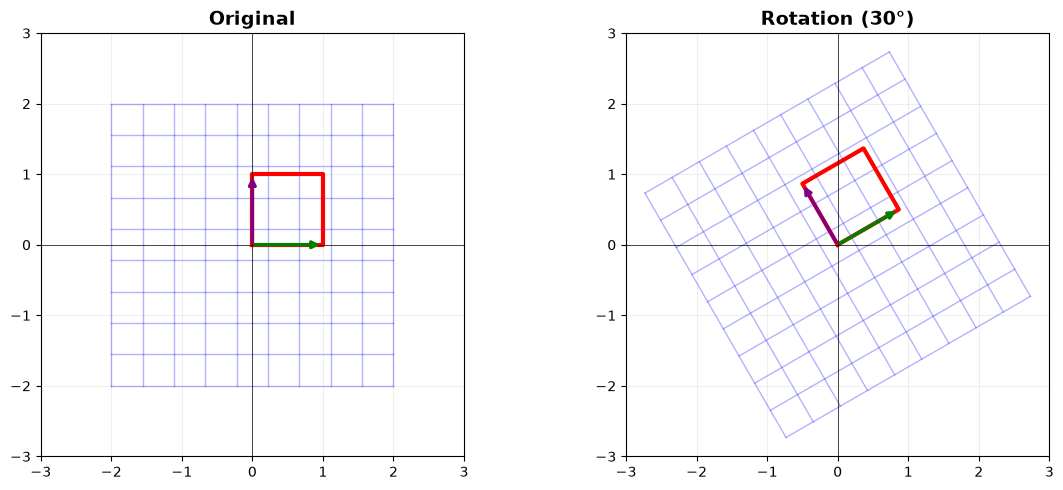

In [19]:
# ROTATION - the grid spins!
angle = math.radians(30)
rotation = [[math.cos(angle), -math.sin(angle)],
            [math.sin(angle), math.cos(angle)]]
plot_transformation(rotation, "Rotation (30°)")

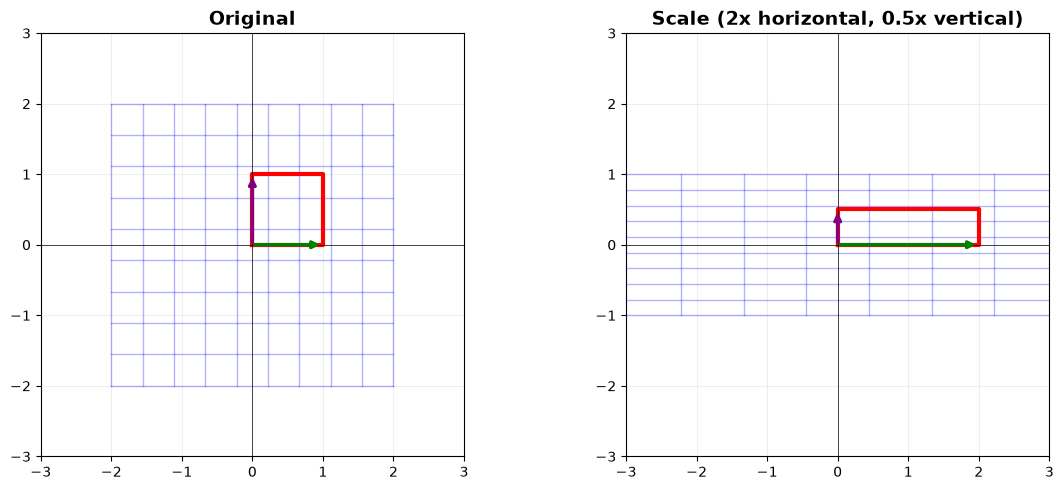

In [20]:
# Scaling - stretch and squish!
plot_transformation([[2, 0], [0, 0.5]], "Scale (2x horizontal, 0.5x vertical)")

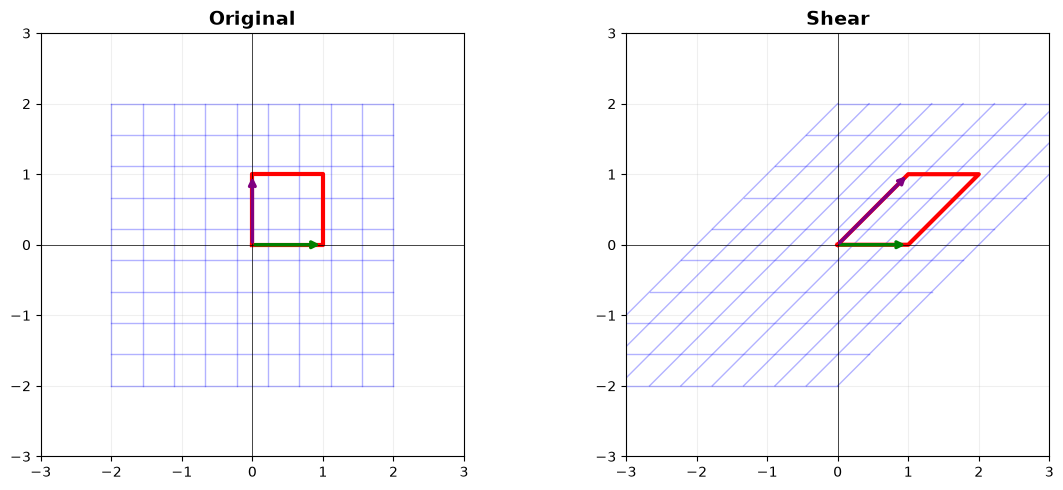

In [21]:
# SHEAR - lean it sideways!
plot_transformation([[1, 1], [0, 1]], "Shear")

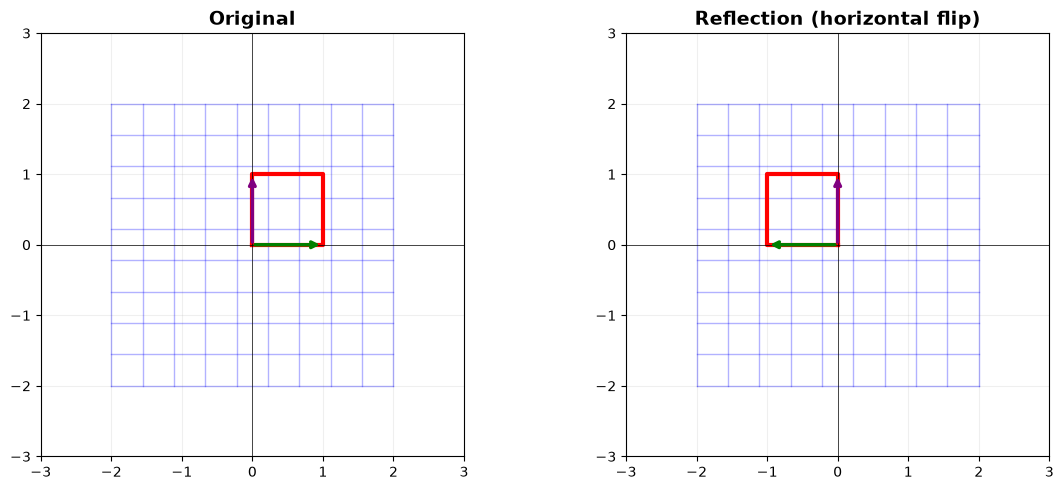

In [22]:
# REFLECTION - flip it!
plot_transformation([[-1, 0], [0, 1]], "Reflection (horizontal flip)")

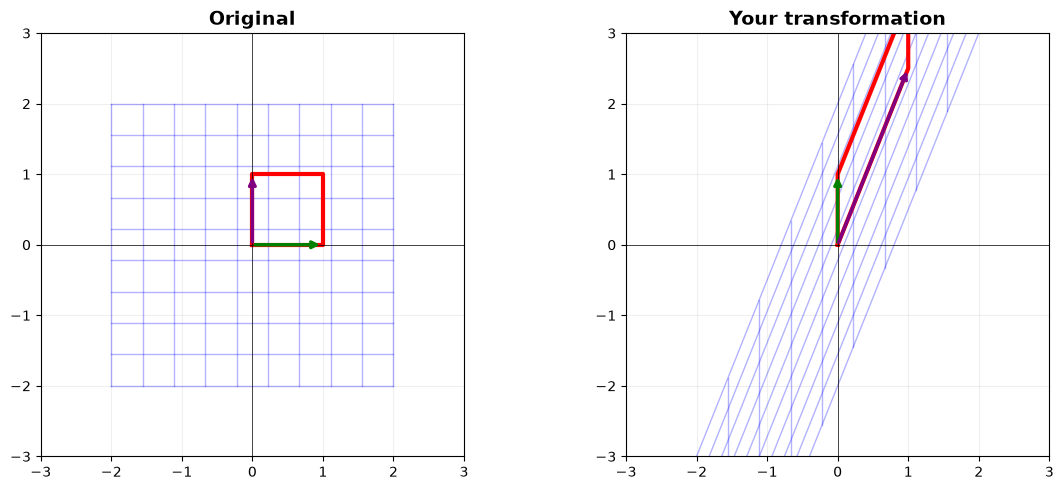

In [23]:
# Try your own transformation!
plot_transformation([[0, 1], [1, 2.5]], "Your transformation")

### 2.3 The Dot Product — Measuring Similarity
The atom of deep learning.

In [24]:
# Two similar vectors (pointing roughly the same way)
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([1.1, 1.9, 3.1])
print(f"Similar vectors dot product: {a @ b:.2f}")  # high!

# Two perpendicular vectors
c = torch.tensor([1.0, 0.0])
d = torch.tensor([0.0, 1.0])
print(f"Perpendicular dot product:    {c @ d:.2f}") # zero!

# Two opposite vectors
e = torch.tensor([1.0, 2.0])
f = torch.tensor([-1.0, -2.0])
print(f"Opposite vectors dot product: {e @ f:.2f}") # negative!

print()
print("This is EXACTLY what attentions does:")
print("  Q · K = how much should this word attend to that word?")

Similar vectors dot product: 14.20
Perpendicular dot product:    0.00
Opposite vectors dot product: -5.00

This is EXACTLY what attentions does:
  Q · K = how much should this word attend to that word?


### 2.5 Matrix Multiplication Speed
Python loops vs PyTorch — feel the difference.

In [26]:
# Multiply two matrices using python loops (the slow way)
def matmul_slow(A, B):
    rows_A, cols_A = A.shape
    rows_B, cols_B = B.shape
    C = torch.zeros(rows_A, cols_B)

    for i in range(rows_A):
        for j in range(cols_B):
            for k in range(cols_A):
                C[i][j] += A[i][k] * B[k][j]

    return C

size = 100
A = torch.randn(size, size)
B = torch.randn(size, size)

# Slow way
start = time.time()
C_slow = matmul_slow(A, B)
slow_time = time.time() - start

# Fast way (PyTorch optimized)
start = time.time()
C_fast = A @ B
fast_time = time.time() - start

print(f"Matrix multiplt {size}x{size}:")
print(f"  Python loops: {slow_time:.4f} seconds")
print(f"  PyTorch @:    {fast_time:.6f} seconds")
print(f"  Speedup:      {slow_time / fast_time:.0f}x faster!")

Matrix multiplt 100x100:
  Python loops: 10.5383 seconds
  PyTorch @:    0.005479 seconds
  Speedup:      1923x faster!


---
# Part 3: PyTorch — GPU Power
*(After Slides 22-27)*

---

In [27]:
x = torch.randn(3, 4)
print(f"Shape: {x.shape}")
print(f"Data pointer: {x.data_ptr()}")

y = x.view(4, 3)
print(f"\nAfter view(4, 3):")
print(f"Shape: {y.shape}")
print(f"Data pointer: {y.data_ptr()}")  # SAME pointer!
print(f"\nSame memory? {x.data_ptr() == y.data_ptr()}")  # True!

Shape: torch.Size([3, 4])
Data pointer: 394870464

After view(4, 3):
Shape: torch.Size([4, 3])
Data pointer: 394870464

Same memory? True


In [28]:
# 1. Tensor internals
x = torch.randn(3, 4)
print(f"Shape: {x.shape}")
print(f"Stride: {x.stride()}")
print(f"Is coniguous: {x.is_contiguous()}")
print(f"Data pointer: {x.data_ptr()}")

y = x.view(4, 3)
print(f"\nReshaped - same memory? {x.data_ptr() == y.data_ptr()}")

z = x.T  # transpose
print(f"Transposed - contiguous? {z.is_contiguous()}")
print(f"Transposed stride: {z.stride()}")   # reversed!

Shape: torch.Size([3, 4])
Stride: (4, 1)
Is coniguous: True
Data pointer: 386199488

Reshaped - same memory? True
Transposed - contiguous? False
Transposed stride: (1, 4)


In [29]:
# 2. The computation graph - peek at it
x = torch.tensor(3.0, requires_grad=True)
y = x**2
z = y + 2 * x + 1

print(f"z = {z.item()}")
print(f"z was created by: {z.grad_fn}")          # AddBackward
print(f"   Which came from: {z.grad_fn.next_functions}")
print(f"y was created by: {y.grad_fn}")          # PowBackward
print("\nPyTorch recorded every operation!")
print("When you call z.backward(), it walks this chain in reverse.")

z = 16.0
z was created by: <AddBackward0 object at 0x73146855cb20>
   Which came from: ((<AddBackward0 object at 0x7314689f8be0>, 0), (None, 0))
y was created by: <PowBackward0 object at 0x731468347430>

PyTorch recorded every operation!
When you call z.backward(), it walks this chain in reverse.


In [30]:
# 3. Gradient accumulation - this gotcha
x = torch.tensor(3.0, requires_grad=True)

y1 = x ** 2
y1.backward()
print(f"After first backward: x.grad = {x.grad}")  # 6.0

x.grad.zero_()
y2 = x ** 2
y2.backward()
print(f"After second backward: x.grad = {x.grad}") # 12.0! Accumulated!

# This is why we call zero_grad()
x.grad.zero_()
y3 = x ** 2
y3.backward()
print(f"After zero + backward: x.grad = {x.grad}") # 6.0 - fresh

After first backward: x.grad = 6.0
After second backward: x.grad = 6.0
After zero + backward: x.grad = 6.0


### 3.1 🔥 CPU vs GPU — The Speed Test
Run this and watch the numbers. This is why GPUs matter.

Size   100×100   | CPU:     1.86ms | GPU:     0.08ms | Speedup:   23.6x
Size   500×500   | CPU:     1.06ms | GPU:     0.11ms | Speedup:    9.7x
Size  1000×1000  | CPU:     7.82ms | GPU:     0.58ms | Speedup:   13.6x
Size  2000×2000  | CPU:    51.46ms | GPU:     4.27ms | Speedup:   12.0x
Size  4000×4000  | CPU:   303.30ms | GPU:    35.12ms | Speedup:    8.6x


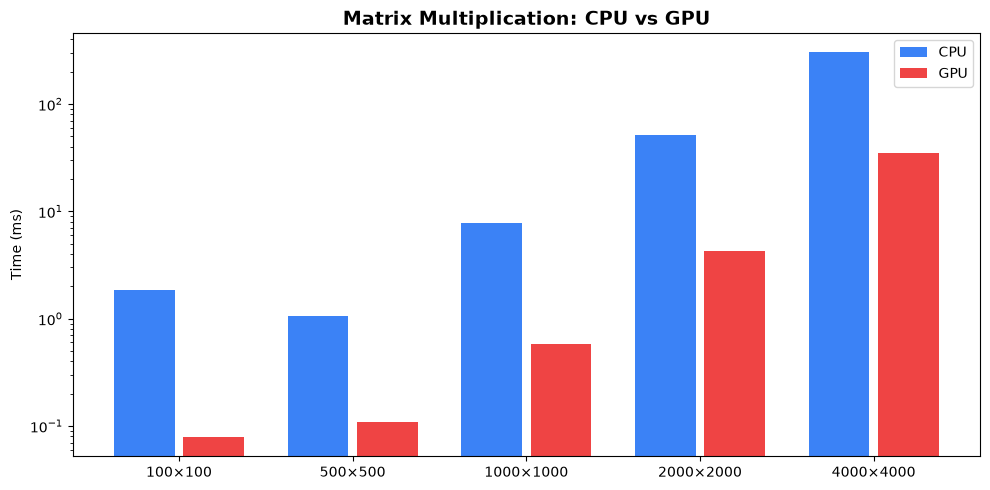


☝️ This is why NVIDIA is worth trillions.


In [31]:
sizes = [100, 500, 1000, 2000, 4000]
cpu_times = []
gpu_times = []

for size in sizes:
    A_cpu = torch.randn(size, size)
    B_cpu = torch.randn(size, size)

    # CPU timing
    start = time.time()
    for _ in range(5):
        _ = A_cpu @ B_cpu
    cpu_time = (time.time() - start) / 5

    if torch.cuda.is_available():
        A_gpu = A_cpu.to("cuda")
        B_gpu = B_cpu.to("cuda")

        # Warmup
        _ = A_gpu @ B_gpu
        torch.cuda.synchronize()

        # GPU timing
        start = time.time()
        for _ in range(5):
            _ = A_gpu @ B_gpu
        torch.cuda.synchronize()
        gpu_time = (time.time() - start) / 5
    else:
        gpu_time = float("nan")

    cpu_times.append(cpu_time * 1000)
    gpu_times.append(gpu_time * 1000)

    speedup = cpu_time / gpu_time if gpu_time > 0 else 0
    print(f"Size {size:>5}×{size:<5} | CPU: {cpu_time*1000:>8.2f}ms | GPU: {gpu_time*1000:>8.2f}ms | Speedup: {speedup:>6.1f}x")

# Plot it
if torch.cuda.is_available():
    fig, ax = plt.subplots(figsize=(10, 5))
    x_pos = range(len(sizes))
    ax.bar([i - 0.2 for i in x_pos], cpu_times, 0.35, label='CPU', color='#3b82f6')
    ax.bar([i + 0.2 for i in x_pos], gpu_times, 0.35, label='GPU', color='#ef4444')
    ax.set_xticks(list(x_pos))
    ax.set_xticklabels([f"{s}×{s}" for s in sizes])
    ax.set_ylabel('Time (ms)')
    ax.set_title('Matrix Multiplication: CPU vs GPU', fontweight='bold', fontsize=14)
    ax.legend()
    ax.set_yscale('log')
    plt.tight_layout()
    plt.show()
    print("\n☝️ This is why NVIDIA is worth trillions.")

### 3.2 Tensor Operations Playground